In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, recall_score)

In [12]:
import os 
os.getcwd()


'd:\\DATA ANALYST PROJECT\\Telecom Churn Prediction\\notebooks'

In [11]:
df = pd.read_csv(r"../data/raw/Telecom-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
if df["SeniorCitizen"].dtype != object:
    df["SeniorCitizen"] = df["SeniorCitizen"].map({1: "Yes", 0: "No"})
df = df.replace({"No internet service": "No", "No phone service": "No"})

print(df.shape)                                  # (7043, 21)
print(df.isnull().sum().sum())                   # 0
print(df["Churn"].value_counts(normalize=True))  # No ~0.735 / Yes ~0.265

(7043, 21)
0
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


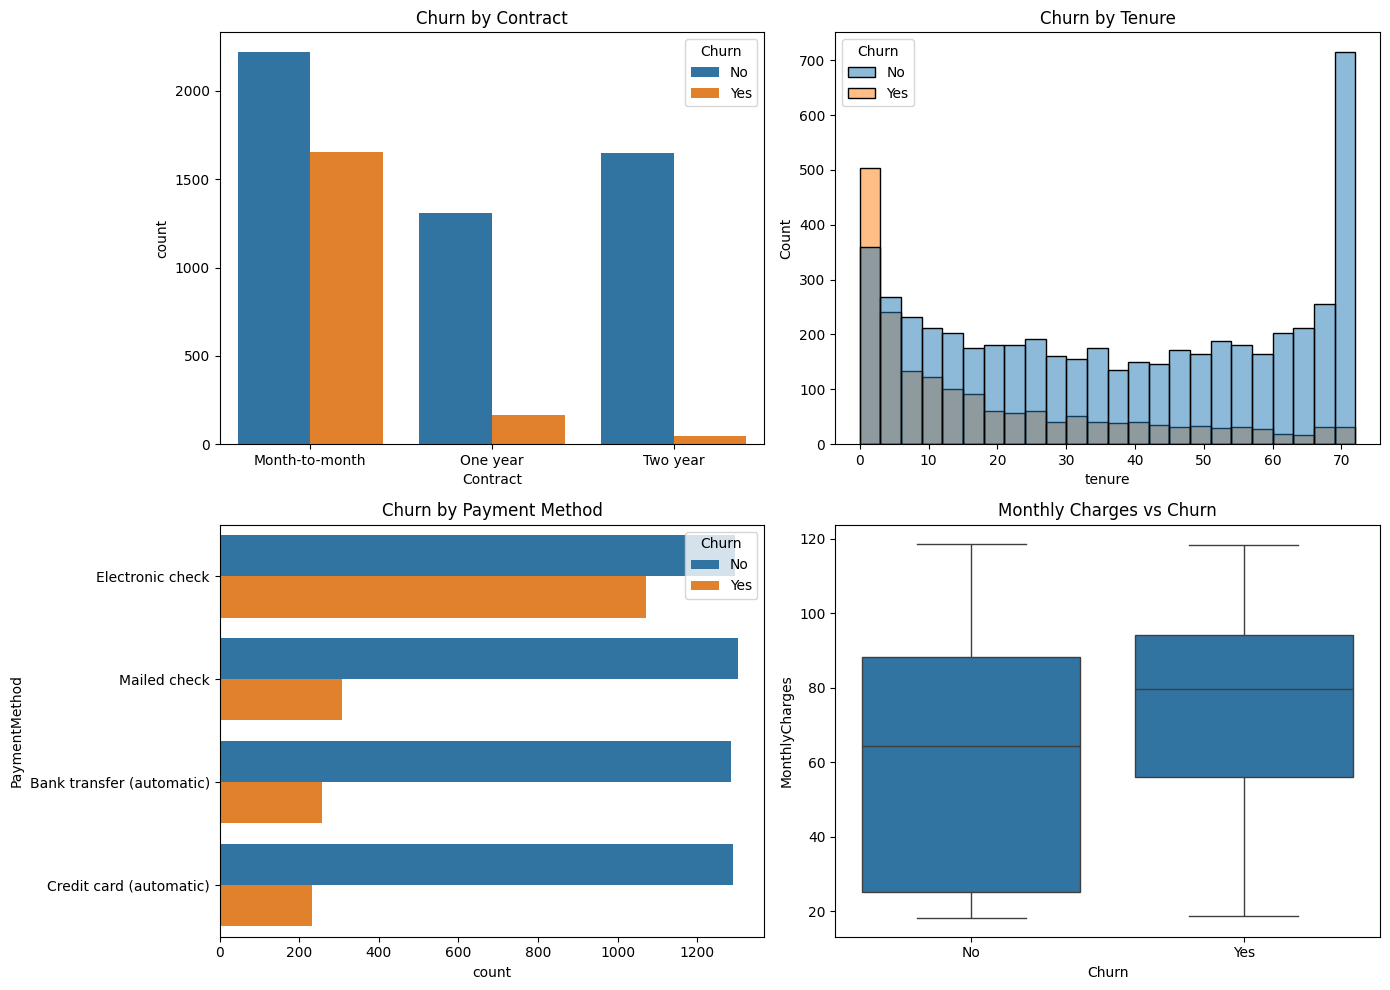

In [16]:
# ================= 3. EDA =================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0,0]); axes[0,0].set_title("Churn by Contract")
sns.histplot(data=df, x="tenure", hue="Churn", bins=24, ax=axes[0,1]); axes[0,1].set_title("Churn by Tenure")
sns.countplot(data=df, y="PaymentMethod", hue="Churn", ax=axes[1,0]); axes[1,0].set_title("Churn by Payment Method")
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1,1]); axes[1,1].set_title("Monthly Charges vs Churn")
plt.tight_layout(); plt.savefig("../outputs/eda.png", dpi=120)

In [17]:
# Churn rate by key dimensions (write these numbers down for the dashboard text):
for col in ["Contract", "PaymentMethod", "InternetService"]:
    print(df.groupby(col)["Churn"].apply(lambda s: (s=="Yes").mean().round(3)), "\n")
# Expected: Month-to-month ~0.43, Two year ~0.03; Electronic check ~0.45; Fiber ~0.42

Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn, dtype: float64 

PaymentMethod
Bank transfer (automatic)    0.167
Credit card (automatic)      0.152
Electronic check             0.453
Mailed check                 0.191
Name: Churn, dtype: float64 

InternetService
DSL            0.190
Fiber optic    0.419
No             0.074
Name: Churn, dtype: float64 



In [18]:
# ================= 4. FEATURES =================
y = (df["Churn"] == "Yes").astype(int)
X = pd.get_dummies(df.drop(columns=["customerID", "Churn"]), drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

In [19]:
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y_train)

proba_test = model.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

print(classification_report(y_test, pred_test))
print("Recall :", round(recall_score(y_test, pred_test), 3))     # target ~0.80
print("ROC-AUC:", round(roc_auc_score(y_test, proba_test), 3))   # ~0.84
print(confusion_matrix(y_test, pred_test))
# If recall < 0.80: lower threshold, e.g. pred_test = (proba_test >= 0.45)


              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1294
           1       0.52      0.80      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.77      0.72      1761
weighted avg       0.81      0.75      0.76      1761

Recall : 0.797
ROC-AUC: 0.846
[[950 344]
 [ 95 372]]


In [20]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
print("RF ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

RF ROC-AUC: 0.8311511869971439


In [21]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()
print("\nTop churn-increasing:\n", coefs.tail(8))
print("\nTop churn-reducing:\n", coefs.head(8))
# Note the top 4 positives — they go on dashboard Page 2 as a text box.


Top churn-increasing:
 SeniorCitizen_Yes                 0.196035
MultipleLines_Yes                 0.278383
StreamingTV_Yes                   0.290459
PaymentMethod_Electronic check    0.371702
PaperlessBilling_Yes              0.374609
StreamingMovies_Yes               0.378481
TotalCharges                      0.515169
InternetService_Fiber optic       1.012429
dtype: float64

Top churn-reducing:
 Contract_Two year    -1.350810
tenure               -1.163137
InternetService_No   -1.128574
Contract_One year    -0.718748
OnlineSecurity_Yes   -0.381805
MonthlyCharges       -0.337265
TechSupport_Yes      -0.321395
Dependents_Yes       -0.229022
dtype: float64


In [23]:

# ================= 7. SCORE ALL CUSTOMERS =================
X_all = X.copy()
X_all[num_cols] = scaler.transform(X_all[num_cols])
df["ChurnProbability"] = model.predict_proba(X_all)[:, 1].round(4)

cutoff = df["ChurnProbability"].quantile(0.85)          # top 15%
df["AtRiskFlag"] = (df["ChurnProbability"] >= cutoff).astype(int)

capture = df.loc[df["AtRiskFlag"]==1, "Churn"].eq("Yes").sum() / df["Churn"].eq("Yes").sum()
print("Top-15% capture of churners:", round(capture, 3))  # resume number

df["RiskBand"] = pd.cut(df["ChurnProbability"], [0, .3, .6, 1.001],
                        labels=["Low", "Medium", "High"])

# Simulated month for the MoM trend (dataset has no dates — label as simulated)
rng = np.random.default_rng(42)
months = pd.date_range("2025-09-01", periods=12, freq="MS")
df["SnapshotMonth"] = rng.choice(months, size=len(df))

df.to_csv("../data/processed/telco_scored.csv", index=False)
print("Saved telco_scored.csv")

Top-15% capture of churners: 0.406
Saved telco_scored.csv


In [24]:
rng = np.random.default_rng(42)
months = pd.date_range("2025-09-01", periods=12, freq="MS")
df["SnapshotMonth"] = rng.choice(months, size=len(df))
df.to_csv("telco_scored.csv", index=False)